# 07 - Comparacao e Promocao

Avalia todos os candidatos no **mesmo split de teste** e aplica o criterio de promocao.

**Entrada:** `models/*/metrics.json` (rodar os notebooks 03 a 06 antes)
**Saidas:** `models/evaluation/metrics_comparison.csv`, graficos, insumo do Model Card

## Criterio de promocao

Declarado em `configs/model_config.yaml` **antes** de qualquer treino:

> Entre os modelos que satisfazem **recall da classe `urgente` >= limiar** e
> **latencia p95 <= teto**, e promovido o de maior **F1-macro** no teste. Empate tecnico
> (diferenca < 1 pp) e resolvido pelo menor p95.

> Ajustar os limiares depois de ver os resultados invalidaria o criterio. Se nenhum
> modelo passar, a mudanca precisa ser registrada explicitamente.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import ensure_dirs, load_config, set_seed

pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

SEED = set_seed()
CONFIG = load_config()
ensure_dirs()
print(f"seed={SEED} | classes={CONFIG['classes']}")

seed=42 | classes=['normal', 'atencao', 'urgente']


## 1. Tabela comparativa

In [2]:
from src.models.experiment import load_comparison_table

comparacao = load_comparison_table()
colunas = ["f1_macro", "recall_urgente", "precision_urgente", "accuracy",
           "latency_p50_ms", "latency_p95_ms", "latency_n_calls", "model_size_mb"]
display(comparacao[colunas].round(4).sort_values("f1_macro", ascending=False))

,f1_macro,recall_urgente,precision_urgente,accuracy,latency_p50_ms,latency_p95_ms,latency_n_calls,model_size_mb
model,,,,,,,,
tfidf_linear_svc,0.7582,0.8118,0.7402,0.7549,1.4539,3.1436,1000,1.226
tfidf_logreg,0.7489,0.7957,0.7309,0.7460,1.6130,2.5905,1000,1.226
tfidf_random_forest,0.7273,0.8414,0.6804,0.7228,150.6078,210.6338,287,72.166
dummy_stratified,0.3388,0.2339,0.2332,0.3579,2.0057,3.6257,1000,0.768
dummy_most_frequent,0.1951,0.0000,0.0000,0.4136,1.3974,2.6660,1000,0.768


## 2. Qualidade x latencia

Os dois eixos que o criterio combina.

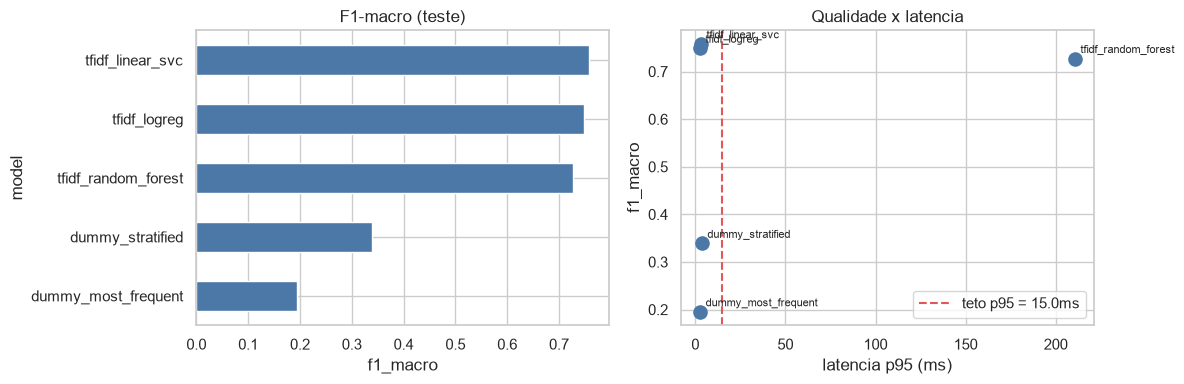

In [3]:
regras = CONFIG["promotion"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ordenado = comparacao.sort_values("f1_macro")
ordenado["f1_macro"].plot(kind="barh", ax=axes[0], color="#4C78A8")
axes[0].set_title("F1-macro (teste)")
axes[0].set_xlabel("f1_macro")

axes[1].scatter(
    comparacao["latency_p95_ms"], comparacao["f1_macro"], s=90, color="#4C78A8"
)
for nome, linha in comparacao.iterrows():
    axes[1].annotate(nome, (linha["latency_p95_ms"], linha["f1_macro"]),
                     fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[1].axvline(regras["max_latency_p95_ms"], color="#E45756", linestyle="--",
                label=f"teto p95 = {regras['max_latency_p95_ms']}ms")
axes[1].set_xlabel("latencia p95 (ms)")
axes[1].set_ylabel("f1_macro")
axes[1].set_title("Qualidade x latencia")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Aplicacao das restricoes

In [4]:
from src.evaluation.promotion import eligible_models

elegibilidade = comparacao[["f1_macro", "recall_urgente", "latency_p95_ms"]].copy()
elegibilidade["passa_recall"] = (
    comparacao["recall_urgente"] >= regras["min_recall_urgente"]
)
elegibilidade["passa_latencia"] = (
    comparacao["latency_p95_ms"] <= regras["max_latency_p95_ms"]
)
elegibilidade["elegivel"] = (
    elegibilidade["passa_recall"] & elegibilidade["passa_latencia"]
)
display(elegibilidade.round(4))

print(f"Limiar recall urgente: {regras['min_recall_urgente']}")
print(f"Teto latencia p95:     {regras['max_latency_p95_ms']} ms")
print(f"Elegiveis: {list(eligible_models(comparacao).index)}")

,f1_macro,recall_urgente,latency_p95_ms,passa_recall,passa_latencia,elegivel
model,,,,,,
dummy_most_frequent,0.1951,0.0000,2.6660,False,True,False
dummy_stratified,0.3388,0.2339,3.6257,False,True,False
tfidf_logreg,0.7489,0.7957,2.5905,True,True,True
tfidf_random_forest,0.7273,0.8414,210.6338,True,False,False
tfidf_linear_svc,0.7582,0.8118,3.1436,True,True,True


Limiar recall urgente: 0.6
Teto latencia p95:     15.0 ms
Elegiveis: ['tfidf_logreg', 'tfidf_linear_svc']


## 4. Modelo promovido

In [5]:
from src.evaluation.promotion import NoEligibleModelError, select_promoted_model

try:
    promovido = select_promoted_model(comparacao)
    print(f"MODELO PROMOVIDO: {promovido}")
    display(comparacao.loc[[promovido], colunas].round(4))
except NoEligibleModelError as erro:
    promovido = None
    print(erro)

MODELO PROMOVIDO: tfidf_logreg


,f1_macro,recall_urgente,precision_urgente,accuracy,latency_p50_ms,latency_p95_ms,latency_n_calls,model_size_mb
model,,,,,,,,
tfidf_logreg,0.7489,0.7957,0.7309,0.746,1.613,2.5905,1000,1.226


> A regra vive em `src/evaluation/promotion.py` e e a mesma consultada pela DAG do
> Airflow e pela API. Se cada um implementasse a propria, divergiriam em silencio sobre
> qual e o modelo de producao.

## 5. Analise de erro do promovido

A pergunta que importa: quantos `urgente` viraram `normal`?

              precision    recall  f1-score   support

      normal       0.74      0.70      0.72       697
     atencao       0.77      0.76      0.76       616
     urgente       0.73      0.80      0.76       372

    accuracy                           0.75      1685
   macro avg       0.74      0.75      0.75      1685
weighted avg       0.75      0.75      0.75      1685



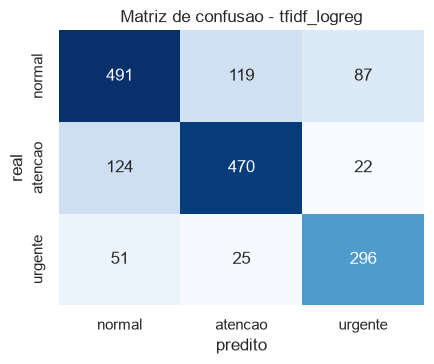

In [6]:
import joblib

from src.config import MODELS_DIR
from src.data.loader import load_split
from src.evaluation.metrics import confusion, report

teste = load_split("test")
modelo = joblib.load(MODELS_DIR / promovido / "model.pkl")
predicoes = modelo.predict(teste["texto"])

print(report(teste["urgencia"], predicoes))

matriz = confusion(teste["urgencia"], predicoes)
fig, ax = plt.subplots(figsize=(4.5, 3.8))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
ax.set_title(f"Matriz de confusao - {promovido}")
plt.tight_layout()
plt.show()

In [7]:
erro_critico = int(matriz.loc["urgente", "normal"])
total_urgente = int(matriz.loc["urgente"].sum())
print(f"'urgente' classificado como 'normal': {erro_critico} de {total_urgente} "
      f"({erro_critico / total_urgente:.1%})")
print("Este e o erro clinicamente caro - registrar no Model Card.")

'urgente' classificado como 'normal': 51 de 372 (13.7%)
Este e o erro clinicamente caro - registrar no Model Card.


## 6. Persistencia

A tabela alimenta o Model Card, a DAG de retreino e a API.

In [8]:
from src.config import EVALUATION_DIR, NOTEBOOK_OUTPUTS
from src.evaluation.promotion import COMPARISON_FILENAME

EVALUATION_DIR.mkdir(parents=True, exist_ok=True)
destino = EVALUATION_DIR / COMPARISON_FILENAME
comparacao.to_csv(destino)
print(f"Comparativo salvo em {destino}")

saida = NOTEBOOK_OUTPUTS / "model_comparison"
saida.mkdir(parents=True, exist_ok=True)
matriz.to_csv(saida / f"confusion_{promovido}.csv")
print(f"Matriz de confusao salva em {saida}")

Comparativo salvo em C:\Users\willi\OneDrive\Documentos\Estudos\Python\tc03-cloud-mlops\models\evaluation\metrics_comparison.csv
Matriz de confusao salva em C:\Users\willi\OneDrive\Documentos\Estudos\Python\tc03-cloud-mlops\notebooks\outputs\model_comparison


## 7. Insumo para o Model Card

Os numeros abaixo vao para [docs/MODEL_CARD.md](../docs/MODEL_CARD.md), que e
**versionado**. Gerar o Model Card dentro de `models/` faria o arquivo existir em disco
sem nunca chegar ao repositorio.

In [9]:
colunas_card = ["f1_macro", "recall_urgente", "latency_p95_ms", "model_size_mb"]
tabela_card = comparacao[colunas_card].round(4)
tabela_card = tabela_card.assign(
    promovido=["SIM" if i == promovido else "" for i in tabela_card.index]
)
print(tabela_card.to_markdown())

| model               |   f1_macro |   recall_urgente |   latency_p95_ms |   model_size_mb | promovido   |
|:--------------------|-----------:|-----------------:|-----------------:|----------------:|:------------|
| dummy_most_frequent |     0.1951 |           0      |           2.666  |           0.768 |             |
| dummy_stratified    |     0.3388 |           0.2339 |           3.6257 |           0.768 |             |
| tfidf_logreg        |     0.7489 |           0.7957 |           2.5905 |           1.226 | SIM         |
| tfidf_random_forest |     0.7273 |           0.8414 |         210.634  |          72.166 |             |
| tfidf_linear_svc    |     0.7582 |           0.8118 |           3.1436 |           1.226 |             |


---

## Conclusao

_Registrar: qual modelo venceu, por que, o que a analise de erro revelou e quais
limitacoes precisam constar no Model Card._

**Proximo passo:** notebook `08_onnx_optimization` (Etapa 4) exporta o modelo promovido
para ONNX Runtime e compara a latencia.